In [66]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# load libraries 
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import tkinter as tk
from tkinter import messagebox
from openpyxl import load_workbook
from pyomo.environ import *
from dateutil.relativedelta import relativedelta


# Load inputs/functions from files
from functionsB120 import importB120, importMonthlyFNF
from ffmPerformanceFunctions import P_FUNCTIONS, rangeDict_Date_WetBFL_start,rangeDict_Date_SP_start,rangeDict_Q_WetPeak_cfsd,rangeDict_Q_WetBFL_cfs,rangeDict_Q_SP_cfs,rangeDict_Q_DS_cfs,rangeDict_Q_FA_cfs, INV_P_FUNCTIONS
from FFM_GeneralFunctions import wyToDate, dateToWY, getWY, getDailyFlowPeriodDF, getSpecVol, getSPRange, cfsToTAF
from functionsFERC import getFERCRangeVol, fallQ_FERC_cfs
from peakFlowRules import * 
from outputFunctions import saveToSheet, addSheetFromWorkbook

# name of model version file 
# (must have existing folder of same name in Output)
#   (must correspond to macros-enabled Excel template (.xlsm) )
model_vrs= 'manuscript_test_01_26'

Run #s:
* 0: Jan 18 report, Feb1 start, Jan1 B120, No Decision
* 1: Feb1 update, Feb1 start, Feb1 B120, Feb decision
* 2: Mar1 update, Mar1 start, Mar1 B120, Mar decision
* 3: Apr1 update, Apr1 start, Apr1 B120, Apr decision
* 4: May1 update, May1 start, May1 B120, May & Jun decision
* 5: Jul1 update, Jul1 start, Known budget, decision - Feb
* 6: Perfect Foresight, Feb1 start, Known budget, year decision -- priorAllocation=0

Eventually would like to create a new class ("Inputs") that had attributes for each run (i.e., within class Inputs: 
 * run1 = Inputs(); 
     * run1.Decision_start = ... 
     * run1.Decision_end = ... 
This would allow run1 attributes to be accessed outside of a loop 

In [67]:
'''In this cell, we collect the user-defined inputs
        - Runtime inputs (set run# and amount released in prior runs)
        - General model settings:
            - Manually override model decision to release a peak?
            - Include FERC volumes (from July-Jan only)
            - Input user-defined season dates
        - Define attributes of each run (dates)
            - Dates
            - Forecast information
            - Decision details  
'''

##Save results to .xls? 
SAVEBOOL = True
POPUP = False
WK_BOOL = False # True to use calibrated W_ks. False, w_k==1 for all k.

WY = 2018

##
# RUNTIME INPUTS : These values are changed between runs
###
run = 6 ## Set Dates of Interest (YYYY,M,D)


# Total **Volume** already allocated  (TAF) 0#
run1_allocation = 47.01
run2_allocation = 35.91
run3_allocation = 69.33
run4_allocation = 287.65
priorAllocation = run1_allocation+run2_allocation+run3_allocation+run4_allocation
# General model settings 
###

# # Forecast: This is where we later would specify which forecasting data input we are using... TBD (lower priority)... might be specified per each run
# B120_BOOL = True
# CNRFC_BOOL = False

# include Wet Season Peak (Operator choice: might depend on available storage, dec/jan flood releases, etc.)
NOPEAK = False

#FERC flows
FERC_BOOL = True
FERC_INDEX = 'CDEC_WYT' #CD' #'CDEC_WYT' # choose FERC flow year-type from ['W','AN','BN','D','CD']

#Force the model to choose a particular exceedance probability 
DECISION_FORCE = False
decision_force_exc = 0

# Date inputs <dt.date objects>
WET_START_DATE = dt.date(WY,2,1)
SPRING_START_DATE = dt.date(WY,5,1)

###
# SET UP: Define run attributes here
###

if run == 0:
    #timing
    Decision_start = dt.date(WY, 1, 30)
    Decision_end = dt.date(WY, 1, 30)
    Future_start = dt.date(WY,2,1)
    Model_end = dt.date(WY+1,1,31)
    #B120
    B120_BOOL=True
    updateMo = 'Jan1'
    run_alias = 'test_JanB120' ##Standardize these aliases to come from the decision start date and decision end date 'Jan30Jan30' to match Fran's code 
    #Decision
    perfectForesight = False
    Decision_BOOL = False
    POPUP_DECISION = False
    SAVEBOOL=False
elif run == 1:
    #timing
    Decision_start = dt.date(WY, 2, 1)
    Future_start = dt.date(WY,3,1)
    Decision_end = Future_start - relativedelta(days=1)
    Model_end = dt.date(WY+1,1,31)
    #B120
    B120_BOOL=True
    updateMo = 'Feb1'
    run_alias = updateMo ###'Feb1Feb29'
    #Decision
    perfectForesight = False
    Decision_BOOL = True
    POPUP_DECISION = True
elif run == 2:
    #timing
    Decision_start = dt.date(WY, 3, 1)
    Future_start = dt.date(WY,4,1)
    Decision_end = Future_start - relativedelta(days=1)
    Model_end = dt.date(WY+1,1,31)
    #B120
    B120_BOOL=True
    updateMo = 'Mar1'
    run_alias = updateMo
    #Decision
    perfectForesight = False
    Decision_BOOL = True
    POPUP_DECISION = True
elif run == 3:
    #timing
    Decision_start = dt.date(WY, 4, 1)
    Future_start = dt.date(WY,5,1)
    Decision_end = Future_start - relativedelta(days=1)
    Model_end = dt.date(WY+1,1,31)
    #B120
    B120_BOOL=True
    updateMo = 'Apr1'
    run_alias = updateMo
    #Decision
    perfectForesight = False
    Decision_BOOL = True
    POPUP_DECISION = True
elif run == 4:
    #timing
    Decision_start = dt.date(WY, 5, 1)
    Future_start = dt.date(WY,7,1)
    Decision_end = Future_start - relativedelta(days=1)
    Model_end = dt.date(WY+1,1,31)
    #B120
    B120_BOOL=True
    updateMo = 'May1'
    run_alias = 'MayJun'
    #Decision
    perfectForesight = False
    Decision_BOOL = True
    POPUP_DECISION = True
elif run == 5:
    #timing
    Decision_start = dt.date(WY, 7, 2) #this will need to be changed to match the end of the periods from the spring pulse run
    Future_start = dt.date(WY+1,2,1)
    Decision_end = Future_start - relativedelta(days=1)
    Model_end = Future_start + relativedelta(days=1)
    #B120
    B120_BOOL=True
    updateMo = 'known'
    run_alias = 'post_Jul'
    #Decision
    perfectForesight = True
    Decision_BOOL = True
    POPUP_DECISION = False
elif run == 6:
    #timing
    Decision_start = dt.date(WY, 2, 1)
    Decision_end = dt.date(WY+1, 1, 31)
    Future_start = Decision_end + relativedelta(days=1)
    Model_end = Decision_end + relativedelta(days=2)
    #B120
    B120_BOOL=True
    updateMo = 'known'
    run_alias = 'perfForesight'
    #Decision
    perfectForesight = True
    Decision_BOOL = True
    priorAllocation = 0
    POPUP_DECISION = False
else: print('Invalid <run> input')




In [68]:
'''In this cell, we manipulate inputs and import the forecast budget: 
        - modify input formats
        - ensure the spring pulse is in one period (either deicion or future)
        - Import the correct B120 budget according to the WY input 
'''

# #####
## Calculate Date Vals (dates to day of water year)
######
WET_START_DOWY = dateToWY(WET_START_DATE)
SPRING_START_DOWY = dateToWY(SPRING_START_DATE)
#####
# Get Spring Pulse into one stage
#####
MAX_Q_WetBFL_cfs = rangeDict_Q_WetBFL_cfs[90]
MAX_Q_SP_cfs = rangeDict_Q_SP_cfs[90]
MAX_Q_DS_cfs = rangeDict_Q_DS_cfs[90]
MAX_DS_START = SPRING_START_DOWY + (np.log(MAX_Q_SP_cfs/MAX_Q_WetBFL_cfs)/np.log(1.13)) + (np.log(MAX_Q_DS_cfs/MAX_Q_SP_cfs)/np.log(0.93))+2
print(wyToDate(MAX_DS_START))
MAX_DS_START = ceil(MAX_DS_START) # round up
print(wyToDate(MAX_DS_START))
MAX_SP_END = MAX_DS_START-1
print ('Max spring end is ' + str(MAX_SP_END))
Decision_start_doWY = dateToWY(Decision_start)
# if Decision_start_doWY in range(SPRING_START_DOWY,MAX_DS_START):
#     Decision_start = SPRING_START_DATE
#     print('%s must not split Spring Pulse/Recession \n %s was changed to:' %(str(Decision_start_doWY), str(Decision_start_doWY)), SPRING_START_DOWY)

Decision_end_doWY = dateToWY(Decision_end)
if Decision_end_doWY in range(SPRING_START_DOWY,MAX_DS_START):
    Decision_end_doWY = MAX_DS_START-1
    Decision_end = wyToDate(Decision_end_doWY, WY)
    print('Decision_end must not split Spring Pulse/Recession \n %s was changed to:' %(str(Decision_end)), wyToDate(MAX_DS_START-1,WY))

Model_end_doWY = dateToWY(Model_end)
if Model_end_doWY in range(SPRING_START_DOWY,MAX_DS_START):
    Model_end_doWY = MAX_DS_START-1
    Model_end = wyToDate(Model_end_doWY,WY)
    print('Model_end must not split Spring Pulse/Recession \n %s was changed to:' %(str(Model_end)), wyToDate(MAX_DS_START-1,WY))
    
Future_start = Decision_end + relativedelta(days=1)

###
# B120 Set-up
###
if B120_BOOL == True:
    if updateMo in ['Dec1','Jan1','Feb1','Mar1','Apr1','May1']:
        if WY > 2010:
            b120 = importB120(str(WY), updateMo)
            Total_AnnualWY_Vols = b120.to_dict()['WY']
            UF_40pile = b120.to_dict()['UF_40pile']
        # elif WY == 2018 and updateMo != 'May1':
        #     b120 = importB120(str(WY), updateMo)
        #     Total_AnnualWY_Vols = b120.to_dict()['WY']
        #     UF_40pile = b120.to_dict()['UF_40pile']
    else:
        monthlyFNF, WY_Total = importMonthlyFNF(WY)
        known_budget = monthlyFNF.loc['40_Feb_Jun',WY]
        UF_40pile = {'99_%ile':known_budget,'90_%ile':known_budget,'75_%ile':known_budget,'50_%ile':known_budget,'25_%ile':known_budget,'10_%ile':known_budget}
        Total_AnnualWY_Vols = {'99_%ile':WY_Total,'90_%ile':WY_Total,'75_%ile':WY_Total,'50_%ile':WY_Total,'25_%ile':WY_Total,'10_%ile':WY_Total}
print(updateMo)


    

2019-06-26
2019-06-27
Max spring end is 268
known


In [69]:
'''
In this cell, we set attributes and naming conventions of the optimization model, including:
        - Arrrays of metric/percentile names (for iteration in Pyomo and result cleaning)
        - Unpackage imported performance functions and match to naming convention
        - <Pk> weights ("k_weights") (weight all percentile performance vals)
        - <W> weights (weight all ANNUAL percentile performance vals - nuianced caution weight)
        - <R> weights by run (relative importance of ANNUAl and REMAINING performance)
        - <A> gives a little bit of value to carryover 
        - Variable bounds for optimization
        - EV of budget/annual WY flow vol by Pk
'''

Metrics = ['Date_WetBFL_start', 'Date_SP_start', 'Q_WetPeak_cfsd','Q_WetBFL_cfs','Q_SP_cfs','Q_DS_cfs','Q_FA_cfs']
date_Metrics = ['Date_WetBFL_start', 'Date_SP_start']
flow_Metrics = ['Q_WetPeak_cfsd','Q_WetBFL_cfs','Q_SP_cfs','Q_DS_cfs','Q_FA_cfs']

Percentiles = ['99_%ile','90_%ile','75_%ile','50_%ile','25_%ile','10_%ile']

performanceFunctions = {}
for i in range(len(Metrics)):
        performanceFunctions[Metrics[i]] = P_FUNCTIONS[i]

inv_performanceFunctions={} 
for i in range(len(flow_Metrics)-1):
        inv_performanceFunctions[flow_Metrics[i+1]] = INV_P_FUNCTIONS[i]

k_weights = {'99_%ile':0.1,'90_%ile':0.15,'75_%ile':0.25,'50_%ile':0.25,'25_%ile':0.15,'10_%ile':0.1} # (p_k)

if DECISION_FORCE:
        if decision_force_exc == 0.10: w = {'99_%ile':0.01,'90_%ile':0.01,'75_%ile':0.01,'50_%ile':0.01,'25_%ile':0.01,'10_%ile':10}
        elif decision_force_exc == 0.25: w = {'99_%ile':0.01,'90_%ile':0.01,'75_%ile':0.01,'50_%ile':0.01,'25_%ile':10,'10_%ile':0.01}
        elif decision_force_exc == 0.50: w = {'99_%ile':0.01,'90_%ile':0.01,'75_%ile':0.01,'50_%ile':10,'25_%ile':0.01,'10_%ile':0.01}
        elif decision_force_exc == 0.75: w = {'99_%ile':0.01,'90_%ile':0.01,'75_%ile':10,'50_%ile':0.01,'25_%ile':0.01,'10_%ile':0.01}
        elif decision_force_exc == 0.90: w = {'99_%ile':0.01,'90_%ile':10,'75_%ile':0.01,'50_%ile':0.01,'25_%ile':0.01,'10_%ile':0.01}
        elif decision_force_exc == 0.99: w = {'99_%ile':10,'90_%ile':0.01,'75_%ile':0.01,'50_%ile':0.01,'25_%ile':0.01,'10_%ile':0.01}
elif WK_BOOL:
        #w_k changes for run numbers, comes from Calibration GA code
        if run == 1:
                w = {'99_%ile':0.27111229,'90_%ile':0.32084137,'75_%ile':0.31938738,'50_%ile':0.013444,'25_%ile':0.07134377,'10_%ile':0.00387119}
        elif run == 2:
                w = {'99_%ile':0.25403932,'90_%ile':0.12321231,'75_%ile':0.12244886,'50_%ile':0.29050526,'25_%ile':0.00122078,'10_%ile':0.20857346}
        elif run == 3:
                w = {'99_%ile':0.06799147,'90_%ile':0.45405015,'75_%ile':0.102539,'50_%ile':0.33640406,'25_%ile':0.00149373,'10_%ile':0.0375216}
        else: 
                w = {'99_%ile':1,'90_%ile':1,'75_%ile':1,'50_%ile':1,'25_%ile':1,'10_%ile':1}
else:
        #Code for constant w_k
        w = {'99_%ile':1,'90_%ile':1,'75_%ile':1,'50_%ile':1,'25_%ile':1,'10_%ile':1}

#r ranks relative functionality of AF and SF
#r_by_run = {0:1,1:0,2:0.99,3:0.99,4:0.005,5:0.01,6:0.01}
# r = 0.001
# evenSmallerNum = r * .00001
# a = evenSmallerNum
a=1


# Upper and lower bounds of the decision metrics, imported from ffmPerformanceFunctions.py
ffm_lb = {'Date_WetBFL_start':rangeDict_Date_WetBFL_start[10],
        'Date_SP_start':rangeDict_Date_SP_start[10],
        'Q_WetPeak_cfsd':0,
        'Q_WetBFL_cfs':0,
        'Q_SP_cfs':0,
        'Q_DS_cfs':0,
        'Q_FA_cfs':0}
        
ffm_ub = {'Date_WetBFL_start':rangeDict_Date_WetBFL_start[90],
        'Date_SP_start':rangeDict_Date_SP_start[90],
        'Q_WetPeak_cfsd':rangeDict_Q_WetPeak_cfsd[90],
        'Q_WetBFL_cfs':rangeDict_Q_WetBFL_cfs[90],
        'Q_SP_cfs':rangeDict_Q_SP_cfs[90],
        'Q_DS_cfs':rangeDict_Q_DS_cfs[90],
        'Q_FA_cfs':rangeDict_Q_FA_cfs[90]}

#These are used to help the model decide when to release peak flows
expectedValue_AnnualFlow = sum( (k_weights[i]*Total_AnnualWY_Vols[i]) for i in Percentiles)
expectedValue_UF40pile = sum( (k_weights[i]*UF_40pile[i]) for i in Percentiles) # should add a caution modifier to this trained on historical b120 EV accuracy

print(w)


{'99_%ile': 1, '90_%ile': 1, '75_%ile': 1, '50_%ile': 1, '25_%ile': 1, '10_%ile': 1}


In [70]:
'''This cell applies a risk aversion scaling for runs where 99th, 90th, or 75th forecast budgets 
may be insufficient to meet minimum funtional flow schedule'''

OTHER_VOL = 0
if FERC_BOOL:
    OTHER_VOL = getFERCRangeVol(FERC_INDEX, Decision_start, Model_end)
    print(OTHER_VOL)
Q_WetPeak_cfsd_MIN = 0

if NOPEAK == 0 and run == 1: 
    for K in Percentiles:
        if expectedValue_UF40pile < (0.4 * p34_taf):
            peak_dur = 0 #No peak
        elif expectedValue_UF40pile < (0.4 * p50_taf):
            peak_dur = 3 #3 days
        elif expectedValue_UF40pile < (0.4 * p75_taf):
            peak_dur = 5 #5 days
        else: 
            peak_dur = 10 #10 days
    
    Q_WetPeak_cfsd_MIN = peak_dur * (8500 - rangeDict_Q_WetBFL_cfs[10])
    print(peak_dur, Q_WetPeak_cfsd_MIN)

def endRamp_DOWY(Q_start, Q_stop, dowy_start, r):
    t = np.log(Q_stop/Q_start) / np.log(r)
    return dowy_start + t


sp_peak_date = endRamp_DOWY(rangeDict_Q_WetBFL_cfs[10], rangeDict_Q_SP_cfs[10], SPRING_START_DOWY, 1.13)
sp_end_date = endRamp_DOWY(rangeDict_Q_SP_cfs[10], rangeDict_Q_DS_cfs[10], sp_peak_date, 0.93) + 1

MIN_ANN_VOL = getSpecVol(START_DATE=Decision_start, 
                             END_DATE=Model_end, 
                             doWY_WetBFL_start = WET_START_DOWY,
                             doWY_SP_start= SPRING_START_DOWY,
                             doWY_SP_peak=sp_peak_date, 
                             doWY_SP_stop=sp_end_date, 
                             Q_WetPeak_cfsd=Q_WetPeak_cfsd_MIN, 
                             Q_WetBFL_cfs= rangeDict_Q_WetBFL_cfs[10], 
                             Q_SP_cfs = rangeDict_Q_SP_cfs[10], 
                             Q_DS_cfs= rangeDict_Q_DS_cfs[10], 
                             Q_FA_cfs=rangeDict_Q_FA_cfs[10],
                             MAX_SP_END=MAX_SP_END) 

logn = np.geomspace(1,2,len(Percentiles))
ones = np.ones(len(Percentiles))
borrowedV_costWeight = ones
# print(logn)
print('FERC is '+ str(OTHER_VOL))
print('minimum annual volume: ' +str(MIN_ANN_VOL))

#This gives the maximum value of the correction factor: continuous_spring_corrector = cfsToTAF(rangeDict_Q_SP_cfs[10]+rangeDict_Q_DS_cfs[10])
shortageV={}
decision_str = ''
print(UF_40pile)
for i, pile in enumerate(Percentiles):
    if UF_40pile[pile] + OTHER_VOL - priorAllocation < MIN_ANN_VOL: #+ 1.97: #+ continuous_spring_corrector:
        shortageV[pile] = MIN_ANN_VOL - (UF_40pile[pile] + OTHER_VOL - priorAllocation)
        UF_40pile[pile] = MIN_ANN_VOL - OTHER_VOL + priorAllocation #+ 1.97 #+ continuous_spring_corrector
        w[pile] = w[pile] * borrowedV_costWeight[i]
        print(str(pile) + ' volume budget faced a shortage of '+str(shortageV[pile]) + '. Changed to Min Annual Volume, UF 40pct F-J = ' + str(UF_40pile[pile]) + ' and w_k_weight multiplied by ' + str(borrowedV_costWeight[i]))
        decision_str += str(pile) + ' volume budget faced a shortage of '+str(shortageV[pile])+ '. Changed to Min Annual Volume, UF 40pct F-J = ' + str(UF_40pile[pile]) + ' and k_weight multiplied by ' + str(borrowedV_costWeight[i]) + ' '

88.09012007042254
FERC is 88.09012007042254
minimum annual volume: 186.60633666573804
{'99_%ile': 547.2272, '90_%ile': 547.2272, '75_%ile': 547.2272, '50_%ile': 547.2272, '25_%ile': 547.2272, '10_%ile': 547.2272}


In [71]:
'''
THIS IS WHERE THE OPTIMIATION HAPPENS! 
    - Create Pyomo model
    - Create variables to be optimized 
    - Create objective function 
    - Constraints
    - Solve with 'IPOPT' solver 
    - Print Pyomo outputs
'''

#PYOMO MODEL AND CONSTRAINTS
def bnds(model, i, j=0):
    return (ffm_lb[i],ffm_ub[i])
def initials(model, i, j=0):
    return ffm_lb[i] + 0.001

domain = {'Date_WetBFL_start':pyomo.environ.PositiveIntegers,
        'Date_SP_start':pyomo.environ.PositiveIntegers,
        'Q_WetPeak_cfsd':pyomo.environ.PositiveReals,
        'Q_WetBFL_cfs':pyomo.environ.PositiveReals,
        'Q_SP_cfs':pyomo.environ.PositiveReals,
        'Q_DS_cfs':pyomo.environ.PositiveReals,
        'Q_FA_cfs':pyomo.environ.PositiveReals}
def dom(model, i, k=0):
    return (domain[i])

model = ConcreteModel()

model.Metrics = Set(initialize=flow_Metrics)
model.Percentiles = Set(initialize=Percentiles)

##
# VARIABLE CREATION
##

#FFM Decisions
model.FFM_decision = Var(model.Metrics, within=dom, bounds=bnds, initialize=initials)
model.FFM = Var(model.Metrics, model.Percentiles, domain=dom, bounds=bnds, initialize=initials)
model.SP_peak_date_decision = Var(within=PositiveReals, initialize =(SPRING_START_DOWY +1) )
model.SP_peak_date = Var(model.Percentiles, within=PositiveReals, initialize =(SPRING_START_DOWY +1))
model.DS_start_date_decision = Var(within=PositiveReals,  initialize =(SPRING_START_DOWY +2))
model.DS_start_date = Var(model.Percentiles, within=PositiveReals, initialize =(SPRING_START_DOWY +2))

model.Volumes = Var(model.Percentiles, within=PositiveReals)
model.Volume_decision = Var(within=PositiveReals)
model.S1_FFRI = Var(within=PositiveReals, bounds=(10,90))
model.S2_FFRI_k = Var(model.Percentiles,within=PositiveReals, bounds=(10,90))


#Objective Function
model.stageDifference_pos = Var(model.Percentiles, within=NonNegativeReals, bounds=(0,80), initialize = 10)
model.stageDifference_neg = Var(model.Percentiles, within=NonPositiveReals, bounds=(-80,0), initialize = -10)
model.CS_k = Var(model.Percentiles, within=NonNegativeReals, bounds=(0,None), initialize = .00001)

##
# OBJECTIVE FUNCTION
##

def abs(model, K):
    return (model.stageDifference_pos[K] - model.stageDifference_neg[K])

# # OBJECTIVE: MAXIMIZE (the minimum of each ffm) FOR EACH PERCENTILE 
# model.value = Objective(expr= sum((k_weights[i] * w[i] * ( abs(model,i) +  ((0) + (100 * model.CS_k[i])))
#                                   for i in Percentiles)), sense=minimize)

# OBJECTIVE: MAXIMIZE (the minimum of each ffm) FOR EACH PERCENTILE 
model.value = Objective(expr= sum((k_weights[i] * w[i] * (( abs(model,i)**2) +  ((0) + (80* model.CS_k[i])))
                                  for i in Percentiles)), sense=minimize)

###
# CONSTRAINTS
##


#all seasons, 99_%ile
def S1FFRIDecision(model,M):
    if Decision_BOOL == False:
        performance = 1e-15
    elif M == 'Q_WetPeak_cfsd':
        return Constraint.Skip
    else: performance = performanceFunctions[M](model.FFM_decision[M])
    return model.S1_FFRI == performance 

                                                                      
model.S1_const = Constraint(model.Metrics,rule=S1FFRIDecision)



#all seasons
def S2FFRI(model,K,M):
    if M == 'Q_WetPeak_cfsd':
        return Constraint.Skip
    else: performance = performanceFunctions[M](model.FFM[M,K])
    return model.S2_FFRI_k[K] == performance 
model.S2_const = Constraint(model.Percentiles,model.Metrics,rule=S2FFRI)

def absoluteDifference(model, K):
    difference = model.S1_FFRI - model.S2_FFRI_k[K]
    return difference == (model.stageDifference_pos[K] + model.stageDifference_neg[K])
model.absDiff_const = Constraint(model.Percentiles, rule=absoluteDifference)


#REMOVED AF RF:
                # ##AF_k<=Phi_ik
                # #all seasons, 99_%ile
                # def AnnualPerformanceDecision(model,K,M):
                #     if Decision_BOOL == False:
                #         performance = 1e-15
                #     elif M == 'Q_WetPeak_cfsd':# and expectedValue_AnnualFlow <= NOPEAK_CUTOFF:
                #         #performance = performanceFunctions['Q_WetBFL_cfs'](model.FFM_decision['Q_WetBFL_cfs'])
                #         return Constraint.Skip
                #     else: performance = performanceFunctions[M](model.FFM_decision[M])
                #     return model.AF_k[K] <= performance 

                # def AnnualPerformance(model,K,M):
                #     if M == 'Q_WetPeak_cfsd':# and expectedValue_AnnualFlow <= NOPEAK_CUTOFF:
                #         # performance = performanceFunctions['Q_WetBFL_cfs'](model.FFM['Q_WetBFL_cfs',K])
                #         return Constraint.Skip
                #     else: performance = performanceFunctions[M](model.FFM[M,K])
                #     return model.AF_k[K] <= performance
                                                                                    
                # model.AF_const0 = Constraint(model.Percentiles,model.Metrics,rule=AnnualPerformanceDecision)
                # model.AF_const1 = Constraint(model.Percentiles,model.Metrics,rule=AnnualPerformance)

                # ##RF_k<=Phi_ik
                # #all seasons
                # def FuturePerformance(model,K,M):
                #     if M == 'Q_WetPeak_cfsd':# and expectedValue_AnnualFlow <= NOPEAK_CUTOFF:
                #         return Constraint.Skip
                #         # performance = performanceFunctions['Q_WetBFL_cfs'](model.FFM['Q_WetBFL_cfs',K])
                #     else: performance = performanceFunctions[M](model.FFM[M,K])
                #     return model.RF_k[K] <= performance 
                # model.RF_const = Constraint(model.Percentiles,model.Metrics,rule=FuturePerformance)

                # def consistentIndex(model,M,K):
                #     if M in ['Q_WetBFL_cfs','Q_WetPeak_cfsd']:
                #         return Constraint.Skip
                #     else: 
                #         wetBFL_performance = performanceFunctions['Q_WetBFL_cfs'](model.FFM['Q_WetBFL_cfs',K])
                #         other_performance = performanceFunctions[M](model.FFM[M,K])
                #         return wetBFL_performance == other_performance
                # def consistentIndex_Decision(model,M):
                #     if M in ['Q_WetBFL_cfs','Q_WetPeak_cfsd']:
                #         return Constraint.Skip
                #     else: 
                #         wetBFL_performance = performanceFunctions['Q_WetBFL_cfs'](model.FFM_decision['Q_WetBFL_cfs'])
                #         other_performance = performanceFunctions[M](model.FFM_decision[M])
                #         return wetBFL_performance == other_performance
                # model.sameIndex_decision = Constraint(model.Metrics, rule=consistentIndex_Decision)
                # model.sameIndex = Constraint(model.Metrics, model.Percentiles, rule=consistentIndex) 

# def REMOVE(model,M, K='10_%ile'):
#     if M in ['Q_WetBFL_cfs','Q_WetPeak_cfsd']:
#         return Constraint.Skip
#     else: 
#         one_performance = performanceFunctions[M](model.FFM[M,K])
#         other_performance = performanceFunctions[M](model.FFM_decision[M])
#         return one_performance == other_performance
# model.constraintREMOVE = Constraint(model.Metrics, rule=REMOVE)


# Peak Wet Season Rules: customized 
def PeakRules(model, K):
    peak_mag = (8500 - model.FFM['Q_WetBFL_cfs',K])
    if NOPEAK == True:
        return model.FFM['Q_WetPeak_cfsd',K] == 1e-20
    if UF_40pile[K] < (0.4 * p34_taf):
        return model.FFM['Q_WetPeak_cfsd',K] == 1e-20 #No peak
    elif UF_40pile[K] < (0.4 * p50_taf):
        return model.FFM['Q_WetPeak_cfsd',K] == 3 * peak_mag #3 days
    elif UF_40pile[K] < (0.4 * p75_taf):
        return model.FFM['Q_WetPeak_cfsd',K] == 5 * peak_mag #5 days
    else: 
        return model.FFM['Q_WetPeak_cfsd',K] == 10 * peak_mag #10 days

def PeakRulesDecision(model):
    peak_mag = (8500-model.FFM_decision['Q_WetBFL_cfs'])
    if NOPEAK == True:
        return model.FFM_decision['Q_WetPeak_cfsd'] == 1e-20
    if expectedValue_UF40pile < (0.4 * p34_taf): 
        return model.FFM_decision['Q_WetPeak_cfsd'] == 1e-20
    elif expectedValue_UF40pile < (0.4 * p50_taf): 
        return model.FFM_decision['Q_WetPeak_cfsd'] == 3 * peak_mag #3 days
    elif expectedValue_UF40pile < (0.4 * p75_taf): 
        return model.FFM_decision['Q_WetPeak_cfsd'] == 5 * peak_mag #5 days
    else: 
        return model.FFM_decision['Q_WetPeak_cfsd'] == 10 * peak_mag #10 days

model.Peak = Constraint(model.Percentiles, rule=PeakRules)
model.PeakDecision = Constraint(rule=PeakRulesDecision)
    

#Get Spring Peak and End dates! 
def SPPeakDate_dec(model):
    return model.SP_peak_date_decision == (log(model.FFM_decision['Q_SP_cfs']/model.FFM_decision['Q_WetBFL_cfs'])/log(1.13)) + SPRING_START_DOWY
def SPPeakDate_prob(model,K):
    return model.SP_peak_date[K] == (log(model.FFM['Q_SP_cfs',K]/model.FFM['Q_WetBFL_cfs',K])/log(1.13)) + SPRING_START_DOWY
model.SPPeak_dec = Constraint(rule=SPPeakDate_dec)
model.SPPeak_prob = Constraint(model.Percentiles, rule=SPPeakDate_prob)

def DSStartDate_dec(model):
    return model.DS_start_date_decision == (log(model.FFM_decision['Q_DS_cfs']/model.FFM_decision['Q_SP_cfs'])/log(0.93)) + model.SP_peak_date_decision +2 #add two because one full day at peak and +1 for day after last day ## This matches fenc getSPRange()
def DSStartDate_prob(model,K):
    return model.DS_start_date[K] == (log(model.FFM['Q_DS_cfs',K]/model.FFM['Q_SP_cfs',K])/log(0.93)) + model.SP_peak_date[K]+2 #add two because one full day at peak and +1 for day after last day ## This matches fenc getSPRange()
model.DSStart_dec = Constraint(rule=DSStartDate_dec)
model.DSStart_prob = Constraint(model.Percentiles, rule=DSStartDate_prob)

#get dates in correct order
def relDates(model,K):
    return model.SP_peak_date[K] <= model.DS_start_date[K]
model.relDates1 = Constraint(expr=model.SP_peak_date_decision <= model.DS_start_date_decision)
model.relDates2 = Constraint(model.Percentiles, rule=relDates)

#These are used to print volume decisions at the end, not in the optimization and DO NOT include any FERC flows
def calculateVols(model,K):
    if FERC_BOOL == True:
        ferc_decision = getFERCRangeVol(FERC_INDEX, Decision_start, Decision_end)
        ferc_future = getFERCRangeVol(FERC_INDEX, Future_start, Model_end)
    else: 
        ferc_decision = 0
        ferc_future = 0

    if Decision_BOOL == False:
        decisionVolume = 0
        ferc_decision = 0
    else:
        decisionVolume = getSpecVol(START_DATE=Decision_start, END_DATE=Decision_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, doWY_SP_peak=model.SP_peak_date_decision, doWY_SP_stop=model.DS_start_date_decision-1, Q_WetPeak_cfsd=model.FFM_decision[Metrics[2]], Q_WetBFL_cfs=model.FFM_decision[Metrics[3]], Q_SP_cfs=model.FFM_decision[Metrics[4]], Q_DS_cfs=model.FFM_decision[Metrics[5]], Q_FA_cfs=model.FFM_decision[Metrics[6]], MAX_SP_END=MAX_SP_END)
    
    if perfectForesight == True:
        futureVolume = 0
        ferc_future=0
    else:
        futureVolume = getSpecVol(START_DATE=Future_start, END_DATE=Model_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, doWY_SP_peak=model.SP_peak_date[K], doWY_SP_stop=model.DS_start_date[K]-1, Q_WetPeak_cfsd=model.FFM[Metrics[2],K], Q_WetBFL_cfs=model.FFM[Metrics[3],K], Q_SP_cfs=model.FFM[Metrics[4],K], Q_DS_cfs=model.FFM[Metrics[5],K], Q_FA_cfs=model.FFM[Metrics[6],K], MAX_SP_END=MAX_SP_END) 

    return model.Volumes[K] == decisionVolume + futureVolume + priorAllocation + model.CS_k[K] - ferc_future - ferc_decision

def calculateVol_decision(model,K):
    if Decision_BOOL == False:
        decisionVolume = 0
    else: 
        decisionVolume = getSpecVol(START_DATE=Decision_start, END_DATE=Decision_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, doWY_SP_peak=model.SP_peak_date_decision, doWY_SP_stop=model.DS_start_date_decision, Q_WetPeak_cfsd=model.FFM_decision[Metrics[2]], Q_WetBFL_cfs=model.FFM_decision[Metrics[3]], Q_SP_cfs=model.FFM_decision[Metrics[4]], Q_DS_cfs=model.FFM_decision[Metrics[5]], Q_FA_cfs=model.FFM_decision[Metrics[6]], MAX_SP_END=MAX_SP_END)
    return model.Volume_decision == decisionVolume
model.Vols = Constraint(model.Percentiles, rule=calculateVols)
model.decision_volume = Constraint(rule=calculateVol_decision)

#Conservation of Mass
def ConservationMass(model,K):
    if FERC_BOOL == True:
        ferc_decision = getFERCRangeVol(FERC_INDEX, Decision_start, Decision_end)
        ferc_future = getFERCRangeVol(FERC_INDEX, Future_start, Model_end)
    else: 
        ferc_decision = 0
        ferc_future = 0

    if Decision_BOOL == False:
        decisionVolume = 0
        ferc_decision = 0
    else:
        decisionVolume = getSpecVol(START_DATE=Decision_start, END_DATE=Decision_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, doWY_SP_peak=model.SP_peak_date_decision, doWY_SP_stop=model.DS_start_date_decision-1, Q_WetPeak_cfsd=model.FFM_decision[Metrics[2]], Q_WetBFL_cfs=model.FFM_decision[Metrics[3]], Q_SP_cfs=model.FFM_decision[Metrics[4]], Q_DS_cfs=model.FFM_decision[Metrics[5]], Q_FA_cfs=model.FFM_decision[Metrics[6]], MAX_SP_END=MAX_SP_END) 
   
    if perfectForesight == True or (B120_BOOL==True and (Decision_start.month >= 7 and Decision_start.month < 12)):
        futureVolume = 0 
        ferc_future = 0
    else:
        futureVolume = getSpecVol(START_DATE=Future_start, END_DATE=Model_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, doWY_SP_peak=model.SP_peak_date[K], doWY_SP_stop=model.DS_start_date[K]-1, Q_WetPeak_cfsd=model.FFM[Metrics[2],K], Q_WetBFL_cfs=model.FFM[Metrics[3],K], Q_SP_cfs=model.FFM[Metrics[4],K], Q_DS_cfs=model.FFM[Metrics[5],K], Q_FA_cfs=model.FFM[Metrics[6],K], MAX_SP_END=MAX_SP_END) 
    
    remainingFlowBudget = UF_40pile[K] - priorAllocation
    fercContribution = ferc_decision + ferc_future
    return model.CS_k[K] + decisionVolume + futureVolume - fercContribution == remainingFlowBudget 
model.ConsMass = Constraint(Percentiles,rule=ConservationMass)


# #Additioanl FERC constraints:
# if FERC_BOOL == True:
#     def fercFall(model, K): #Fall pulse must be >= FERC pulse 
#         return model.FFM['Q_FA_cfs',K] >= fallQ_FERC_cfs(FERC_INDEX)
#     model.FERCFall = Constraint(Percentiles, rule=fercFall)
#     model.FERCFall_decision = Constraint(rule=model.FFM_decision['Q_FA_cfs'] >= fallQ_FERC_cfs(FERC_INDEX))


##
# SOVE! 
##

opt = SolverFactory('IPOPT')
result_obj = opt.solve(model, tee=True, symbolic_solver_labels=True) 

# # MIP attempt
# opt = SolverFactory('mindtpy') 
# result_obj = opt.solve(model, mip_solver='glpk', nlp_solver='ipopt', tee=True)


print(result_obj.solver.termination_condition)
print('Solver Status: ',result_obj.solver.status)

## NOTE: Uncommment below to print lengthy optimization results for troubleshooting 
# model.pprint()

Ipopt 3.13.3: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.13.3, running with linear solver mumps.
NOTE: Other linear solvers might be more efficient (see Ipopt documentation).

Number of nonzeros in equality constraint Jacobian...:      253
Number of nonzeros in inequality constraint Jacobian.:       14
Number of nonzeros in Lagrangian Hessian.............:       60

Total number of variables............................:       81
                     variables with only lower bounds:       27
                variables with lower and upper bounds:       54
                     variables with only upper bounds:        0
Total 

Modeled decision Volume is 635.27 (TAF)
Wet Peak (if in Decision period): 74.11 (TAF)
S1 Decision is 55.8
              SP_peak_date_decision  SP_peak_date  DS_start_date  \
index                                                              
10_%ile                         NaN    225.595097     266.351720   
25_%ile                         NaN    225.595098     266.351721   
50_%ile                         NaN    225.595098     266.351721   
75_%ile                         NaN    225.595098     266.351721   
90_%ile                         NaN    225.595098     266.351721   
99_%ile                         NaN    225.595097     266.351720   
FFM_decision             225.595098    225.595098     266.351721   

              DS_start_date_decision  Carryover    S1_FFRI  S2_FFRI_k  \
index                                                                   
10_%ile                          NaN        0.0  55.803001  55.802997   
25_%ile                          NaN        0.0  55.803001  55

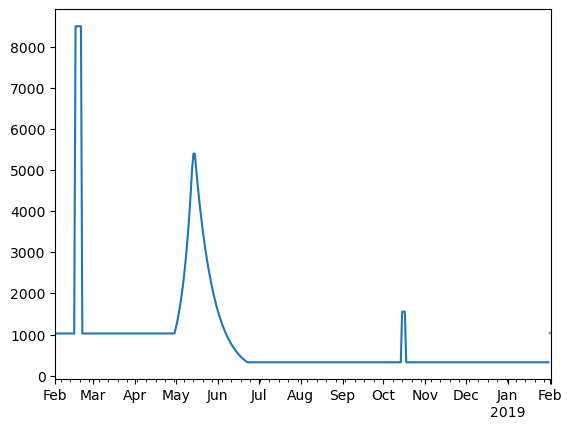

In [72]:
'''
This cell unpackages data from Pyomo model.results and stores in pandas dataframes (ready to be exported to .xlsx)'''


stage_allocation = model.Volume_decision.value 
if wyToDate(WET_START_DOWY, WY=WY) <= Decision_end and wyToDate(WET_START_DOWY, WY=WY) >= Decision_start:
    peak_vol_TAF = model.FFM_decision['Q_WetPeak_cfsd'].value * 1.983 /1000
else: peak_vol_TAF = 0
i += 1
decision_str += 'Modeled decision Volume is %.2f (TAF)' %stage_allocation
print(decision_str)
print('Wet Peak (if in Decision period): %.2f (TAF)' %peak_vol_TAF)
print('S1 Decision is %.1f' %model.S1_FFRI.value)

Index = ['Decision',Metrics]
df_decision = pd.DataFrame.from_dict(model.FFM_decision.extract_values(), orient='index', columns=[str(model.FFM_decision)])
df_decision = df_decision.transpose()

#extract get date vals 
vals= pd.DataFrame.from_dict(model.SP_peak_date_decision.extract_values(), orient='index', columns=[str(model.SP_peak_date_decision)])
vals = vals.append(pd.DataFrame.from_dict(model.SP_peak_date.extract_values(), orient='index', columns=[str(model.SP_peak_date)]))
vals['DS_start_date'] = pd.DataFrame.from_dict(model.DS_start_date.extract_values(), orient='index', columns=[str(model.DS_start_date)])
vals = vals.append(pd.DataFrame.from_dict(model.DS_start_date_decision.extract_values(), orient='index', columns=[str(model.DS_start_date_decision)]))
vals['DS_start_date'] = vals['DS_start_date'].fillna(vals['DS_start_date_decision'])
vals['SP_peak_date'] = vals['SP_peak_date'].fillna(vals['SP_peak_date_decision'])
vals['Carryover'] = pd.DataFrame.from_dict(model.CS_k.extract_values(), orient='index',columns=[str(model.CS_k)])
vals['S1_FFRI'] = pd.DataFrame.from_dict({'99_%ile':model.S1_FFRI.value,'90_%ile':model.S1_FFRI.value,'75_%ile':model.S1_FFRI.value,'50_%ile':model.S1_FFRI.value,'25_%ile':model.S1_FFRI.value,'10_%ile':model.S1_FFRI.value}, orient='index',columns=[str(model.S1_FFRI)])
vals['S2_FFRI_k'] = pd.DataFrame.from_dict(model.S2_FFRI_k.extract_values(), orient='index',columns=[str(model.S2_FFRI_k)])
vals['Diff_pos'] = pd.DataFrame.from_dict(model.stageDifference_pos.extract_values(), orient='index',columns=[str(model.stageDifference_pos)])
vals['Diff_neg'] = pd.DataFrame.from_dict(model.stageDifference_neg.extract_values(), orient='index',columns=[str(model.stageDifference_neg)])
vals.index = pd.Series(vals.index).replace(np.nan, 'FFM_decision')
vals = vals.reset_index().groupby('index').max()
print(vals)

#extract decision and future FFM metric results 
df_future = pd.DataFrame.from_dict(model.FFM.extract_values(), orient='index', columns=[str(model.FFM)])
df_future.index = pd.MultiIndex.from_tuples(df_future.index, names=['Metric', 'Percentile'])
df_future = df_future.unstack(0).sort_index(level=1, ascending=False)
df_future.columns = df_future.columns.get_level_values(1)
df = df_decision.append(df_future)
df['DS_start_date'] = vals['DS_start_date']
df['SP_peak_date'] = vals['SP_peak_date']
df['Carryover'] = vals['Carryover']
#print(df)

df2 = pd.DataFrame(index=df.index) 
for col in flow_Metrics:
    df2[col] = performanceFunctions[col](df[col].values)
print(df2)

plt.figure
df_daily = pd.DataFrame(index = pd.date_range(start=Decision_start, end=Model_end, freq='D'))
for index, row in df.iterrows():
    if index == 'FFM_decision':
        df_daily[index] = getDailyFlowPeriodDF(START_DATE=Decision_start, END_DATE=Decision_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, Q_WetPeak_cfsd=row['Q_WetPeak_cfsd'], Q_WetBFL_cfs=row['Q_WetBFL_cfs'], Q_SP_cfs=row['Q_SP_cfs'], Q_DS_cfs=row['Q_DS_cfs'], Q_FA_cfs=row['Q_FA_cfs'])
    else:
        df_daily[index] = getDailyFlowPeriodDF(START_DATE=Future_start, END_DATE=Model_end, doWY_WetBFL_start=WET_START_DOWY, doWY_SP_start=SPRING_START_DOWY, Q_WetPeak_cfsd=row['Q_WetPeak_cfsd'], Q_WetBFL_cfs=row['Q_WetBFL_cfs'], Q_SP_cfs=row['Q_SP_cfs'], Q_DS_cfs=row['Q_DS_cfs'], Q_FA_cfs=row['Q_FA_cfs'])
    df_daily[index].plot()
print(df_daily)
daily_decision_vol = cfsToTAF(df_daily['FFM_decision'].sum())

df_monthly = df_daily.resample('MS').sum() * (1.98211/1000)
df_monthly = df_monthly.transpose()
print(df_monthly)

volumes = pd.DataFrame.from_dict(model.Volumes.extract_values(), orient='index', columns=[str(model.Volumes)])
volumes['B120'] = pd.DataFrame.from_dict(UF_40pile, orient='index')
volumes['Prior Allocations'] = priorAllocation
if run == 'run0': volumes['Daily Aggregated Results'] = cfsToTAF(df_daily.transpose().drop('FFM_decision').sum(axis=1))
elif run == 'run6': volumes['Daily Aggregated Results'] = daily_decision_vol
else:
    volumes['Daily Aggregated Results'] = df_daily.transpose().drop('FFM_decision').sum(axis=1)
    volumes['Daily Aggregated Results'] = cfsToTAF(volumes['Daily Aggregated Results']) + daily_decision_vol
if FERC_BOOL:
    if Decision_BOOL == True:
        ferc_decision = getFERCRangeVol(FERC_INDEX, Decision_start, Decision_end)
    else: ferc_decision = 0
    if perfectForesight == False:
        ferc_future = getFERCRangeVol(FERC_INDEX, Decision_end+dt.timedelta(days=1), Model_end)
    else: ferc_future = 0
else:
    ferc_decision = 0
    ferc_future = 0
if FERC_BOOL: volumes['FERC'] = np.ones(len(volumes)) * (ferc_decision + ferc_future)
else: volumes['FERC'] = np.zeros(len(volumes))
volumes['s1'] = vals.S1_FFRI
volumes['s2'] = vals.S2_FFRI_k


print(volumes)

ferc_stat = FERC_INDEX if FERC_BOOL else 'NA'
df_summary = pd.DataFrame([[updateMo, WY, Decision_start, Decision_end, Model_end, WET_START_DATE, (SPRING_START_DATE, SPRING_START_DOWY), priorAllocation, ferc_stat]], 
                          columns= ['updateMo', 'WY', 'Decision_start', 'Decision_end', 'Model_end', 'wyToDate(WET_START_DOWY)', 'wyToDate(SPRING_START_DOWY)', 'priorAllocation', 'FERC_BOOL'])
df_summary = df_summary.transpose()
print(df_summary)
# df_results = df
# df_totalVols = pd.DataFrame(index=Percentiles)
# df_Performance = pd.DataFrame(index=Percentiles) 
# for j in Seasons:
#     df_totalVols[j+'Volume_season'] = df[j].values + priorAllocations[j]
#     df_Performance[j+'Performance_season'] = performanceFunctions[j](df[j].values + priorAllocations[j])
# df_results['CarryoverStorage_TAF'] = carryover
# df_totalVols['CarryoverStorage_TAF'] = carryover
# df_Performance['AllSeasonsPerformance_objfunc'] = AllSeasonsPerformance
# df_Performance['RemaingingSeasonsPerformance_objfunc'] = RemaingSeasonsPerformance
# df_totalVols['UF_40_FebJun'] = df.index.map(UF_40pile)
# #reorder
# df_results = df_results[['WetSeason_Peak', 'WetSeason_Base','SpringRecession','DrySeason_Base', 'FallPulse','CarryoverStorage_TAF']]

# if FERC_BOOL == True:
#     df_totalVols_NOFERC = df_totalVols.copy()
#     df_FERC_ONLY= df_totalVols.copy()
#     for k in Percentiles:
#         for t in Seasons:
#             df_totalVols_NOFERC.at[k,t+'Volume_season'] = df_totalVols_NOFERC.at[k,t+'Volume_season'] - getFERCVol_Season(FERC_YEAR_TYPE, t)
#             df_FERC_ONLY.at[k,t+'Volume_season'] = getFERCVol_Season(FERC_YEAR_TYPE, t)

# print('Raw results -- no prior allocations:')
# print(df_results)
# print('Revised results -- with prior allocations')
# print(df_totalVols)
# print('Performance results')
# print(df_Performance)

# if FERC_BOOL == True:
#     print('Only Allocation (No FERC):')
#     print(df_totalVols_NOFERC)
#     print('Only Ferc (No Allocation):')
#     print(df_FERC_ONLY)




In [73]:
# if SAVEBOOL == True: 
#     import os 
    
#     if FERC_BOOL==True:
#         path = 'Output/' + model_vrs + '/' + str(WY) + '_FERC_' + model_vrs + '.xlsx'
#     else:
#         path = 'Output/' + model_vrs + '/' + str(WY) + '_' + model_vrs + '.xlsx'

#     if os.path.exists(path) == False:
#         import shutil

#         original = r'Output/' + model_vrs + '/template_'+ model_vrs + '.xlsx'
#         target = path

#         shutil.copyfile(original, target)

#     sheetname = run_alias + '_raw'

#     dfs =(df_summary, volumes, df, df2, df_monthly, df_daily)

#     saveToSheet(dfs, sheetname , path , 2, decision_str)
    





In [74]:
if SAVEBOOL == True: 
    import os 
    import shutil
    import openpyxl as opyx
    
    directory_path = temp_path = 'Output/' + model_vrs
    temp_path = 'Output/' + model_vrs + '/temp'+ str(WY) +'_raw.xlsx'


    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
    
    if os.path.exists(temp_path) == False:

        wb = opyx.Workbook() 
        Sheet_name = wb.sheetnames
        wb.save(filename=temp_path)


    # if FERC_BOOL==True:
    #     path = 'Output/' + model_vrs + '/' + str(WY) + '_FERC_' + model_vrs + '.xlsx'
    # else:
    #     path = 'Output/' + model_vrs + '/' + str(WY) + '_' + model_vrs + '.xlsx'

    sheetname = run_alias + '_raw'

    dfs =(df_summary, volumes, df, df2, df_monthly, df_daily)

    saveToSheet(dfs, sheetname , temp_path , 2, decision_str)

    #addSheetFromWorkbook(temp_path, target_path=path, sheetname=sheetname)

    #os.remove(temp_path)
    





Save Successful [1/2]


In [75]:
'''THIS CODE IS FOR GETTING PERFORMANCE VALS MANUALLY FOR POLICY ALTERNATIVES 
This is not part of the optimization, but is an *add-on tool* to associate performance values with other flows outside of the decision tool
'''

p_arr = [435,	7030,	150,	1376]
print('WetBFL IDX: ',performanceFunctions['Q_WetBFL_cfs'](p_arr[0]) )

print('SP_Peak IDX: ',performanceFunctions['Q_SP_cfs'](p_arr[1]) )

print('DS_BFL IDX: ', performanceFunctions['Q_DS_cfs'](p_arr[2]) )

print('FA_Peak IDX: ', performanceFunctions['Q_FA_cfs'](p_arr[3]) )

z = 20
print('WetBFL Q: ',inv_performanceFunctions['Q_WetBFL_cfs'](z))

print('SP_Peak Q: ',inv_performanceFunctions['Q_SP_cfs'](z))

print('DS_BFL Q: ', inv_performanceFunctions['Q_DS_cfs'](z))

print('FA_Peak Q: ', inv_performanceFunctions['Q_FA_cfs'](z))

WetBFL IDX:  16.117647058823522
SP_Peak IDX:  73.77931034482758
DS_BFL IDX:  7.212543554006999
FA_Peak IDX:  48.6699751861042
WetBFL Q:  492.75000000000017
SP_Peak Q:  2156.2499999999995
DS_BFL Q:  195.8749999999999
FA_Peak Q:  653.8750000000002


In [76]:
### GET MINIMUM B120/Budget Value to meet minimum flows 
sp_peak_date, sp_end_date = getSPRange(dateToWY(dt.date(WY,5,1)),rangeDict_Q_WetBFL_cfs[10], rangeDict_Q_SP_cfs[10], rangeDict_Q_DS_cfs[10])
print(sp_peak_date, sp_end_date)
print(wyToDate(sp_peak_date), wyToDate(sp_end_date), wyToDate(255))
volume_minimum = getSpecVol(START_DATE=dt.date(WY, 2,1), 
                             END_DATE=dt.date(WY+1,1,30), 
                             doWY_WetBFL_start=dateToWY(dt.date(WY,2,1)), 
                             doWY_SP_start=dateToWY(dt.date(WY,5,1)), 
                             doWY_SP_peak=sp_peak_date, 
                             doWY_SP_stop=sp_end_date, 
                             Q_WetPeak_cfsd=0 , 
                             Q_WetBFL_cfs= rangeDict_Q_WetBFL_cfs[10] , 
                             Q_SP_cfs = rangeDict_Q_SP_cfs[10], 
                             Q_DS_cfs= rangeDict_Q_DS_cfs[10], 
                             Q_FA_cfs=rangeDict_Q_FA_cfs[10],
                             MAX_SP_END=MAX_SP_END)
# volume_maximum = getSpecVol(START_DATE=dt.date(WY, 2,1), 
#                              END_DATE=dt.date(WY+1,1,30), 
#                              doWY_WetBFL_start=dateToWY(dt.date(WY,2,1)), 
#                              doWY_SP_start=dateToWY(dt.date(WY,5,1)), 
#                              doWY_SP_peak=sp_peak_date, 
#                              doWY_SP_stop=sp_end_date, 
#                              Q_WetPeak_cfsd=10*rangeDict_Q_SP_cfs[90], 
#                              Q_WetBFL_cfs= rangeDict_Q_WetBFL_cfs[90] , 
#                              Q_SP_cfs = rangeDict_Q_SP_cfs[90], 
#                              Q_DS_cfs= rangeDict_Q_DS_cfs[90], 
#                              Q_FA_cfs=rangeDict_Q_FA_cfs[90])                             
decision_volume_minimum = getSpecVol(START_DATE=Decision_start, 
                             END_DATE=Decision_end, 
                             doWY_WetBFL_start=dateToWY(dt.date(WY,2,1)), 
                             doWY_SP_start=dateToWY(dt.date(WY,5,1)), 
                             doWY_SP_peak=sp_peak_date, 
                             doWY_SP_stop=sp_end_date, 
                             Q_WetPeak_cfsd=0 , 
                             Q_WetBFL_cfs= rangeDict_Q_WetBFL_cfs[10] , 
                             Q_SP_cfs = rangeDict_Q_SP_cfs[10], 
                             Q_DS_cfs= rangeDict_Q_DS_cfs[10], 
                             Q_FA_cfs=rangeDict_Q_FA_cfs[10],
                             MAX_SP_END=MAX_SP_END)

Test_vol = getSpecVol(START_DATE=Decision_start, 
                             END_DATE=Decision_end, 
                             doWY_WetBFL_start=dateToWY(dt.date(WY,2,1)), 
                             doWY_SP_start=dateToWY(dt.date(WY,5,1)), 
                             doWY_SP_peak=231.8641406, 
                             doWY_SP_stop=274.3567106-1, 
                             Q_WetPeak_cfsd=0 , 
                             Q_WetBFL_cfs= 750 , 
                             Q_SP_cfs = 8500, 
                             Q_DS_cfs= 450, 
                             Q_FA_cfs= 2000,
                             MAX_SP_END=MAX_SP_END)
print('Test volume is ', str(Test_vol))

print('Minimum total annual:',volume_minimum)
#print('Maximum total annual:',volume_maximum)
print('Alternative Minimum Release Decision:',decision_volume_minimum)

print('Minimum Wet Season Base Flow (cfs) is: ',rangeDict_Q_WetBFL_cfs[10])
print('Minimum Spring Peak Flow (cfs) is: ',rangeDict_Q_SP_cfs[10])
print('Minimum Dry Season Base Flow (cfs) is ', rangeDict_Q_DS_cfs[10])
print('Maximum Wet Season Base Flow (cfs) is: ',rangeDict_Q_WetBFL_cfs[90])
print('Maximum Spring Peak Flow (cfs) is: ',rangeDict_Q_SP_cfs[90])


222 251
2019-05-11 2019-06-09 2019-06-13
Test volume is  711.4200355896654
Minimum total annual: 184.4157824442756
Alternative Minimum Release Decision: 184.73292004427557
Minimum Wet Season Base Flow (cfs) is:  344
Minimum Spring Peak Flow (cfs) is:  1250
Minimum Dry Season Base Flow (cfs) is  160
Maximum Wet Season Base Flow (cfs) is:  1534
Maximum Spring Peak Flow (cfs) is:  8500


In [77]:
if POPUP and run < 5:
    if run == 0:
        pass
    elif (result_obj.solver.termination_condition == TerminationCondition.infeasible):
        tk.messagebox.showinfo(title='Run output', message='Solver termination "infeasible" (insufficient water to provide minimum flow). Please release alternative minimum flow ' + str(decision_volume_minimum)+'. '+decision_str)
    elif (volumes['AF']['10_%ile']+0.01) < 10: 
        tk.messagebox.showinfo(title='Run output', message='decision volume was less than FFRI 10, ('+ str(daily_decision_vol) + '), release instead the minimum flow: ('+str(decision_volume_minimum)+')'+'. '+decision_str )
    elif volumes['RF']['10_%ile'] < 10: 
        tk.messagebox.showinfo(title='Run output', message='Solver termination "OK", but 25-pctile has FFRI less than 10. Consider alternative minimum flow ' + str(decision_volume_minimum) + ' or the decision volume '+ str(daily_decision_vol)+'. '+decision_str)
    elif volumes['RF']['25_%ile'] < 10: 
        tk.messagebox.showinfo(title='Run output', message='Solver termination "OK", but 25-pctile has FFRI less than 10. Consider alternative minimum flow ' + str(decision_volume_minimum) + ' or the decision volume '+ str(daily_decision_vol)+'. '+decision_str)
    elif volumes['RF']['50_%ile'] < 10: 
        tk.messagebox.showinfo(title='Run output', message='Solver termination "OK", but 50-pctile has FFRI less than 10. Consider alternative minimum flow ' + str(decision_volume_minimum) + ' or the decision volume '+ str(daily_decision_vol)+'. '+decision_str)
    elif volumes['RF']['75_%ile'] < 10: 
        tk.messagebox.showinfo(title='Run output', message='Solver termination "OK", but 75-pctile has FFRI less than 10. Consider alternative minimum flow ' + str(decision_volume_minimum) + ' or the decision volume '+ str(daily_decision_vol)+'. '+decision_str)
    elif volumes['RF']['90_%ile'] < 10: 
        tk.messagebox.showinfo(title='Run output', message='Solver termination "OK", but 90-pctile has FFRI less than 10. Consider alternative minimum flow ' + str(decision_volume_minimum) + ' or the decision volume '+ str(daily_decision_vol) +'. '+decision_str)
    elif volumes['RF']['99_%ile'] < 10: 
        tk.messagebox.showinfo(title='Run output', message='Solver termination "OK", but 99-pctile has FFRI less than 10. Consider alternative minimum flow ' + str(decision_volume_minimum) + ' or the decision volume '+ str(daily_decision_vol)+'. '+decision_str)
    elif POPUP_DECISION: 
        if run==4: tk.messagebox.showinfo(title='Run output', message='Decision volume (daily disagg) is ' + str(daily_decision_vol) + ' or is ' + str(model.Volume_decision.value) + ' with continuous ramping'+'. '+decision_str)
        else:tk.messagebox.showinfo(title='Run output', message='Decision volume is ' + str(daily_decision_vol)+'. '+decision_str)



In [78]:
## This code save a .csv file of the minimum flow regin (FFRI-10) given user-defined inputs

# df_minflow = getDailyFlowPeriodDF(START_DATE=dt.date(2021,2,1), 
#                              END_DATE=dt.date(2022,1,31), 
#                              doWY_WetBFL_start=dateToWY(dt.date(WY,2,1)), 
#                              doWY_SP_start=dateToWY(dt.date(WY,5,1)), 
#                              Q_WetPeak_cfsd=0 , 
#                              Q_WetBFL_cfs= rangeDict_Q_WetBFL_cfs[10] , 
#                              Q_SP_cfs = rangeDict_Q_SP_cfs[10], 
#                              Q_DS_cfs= rangeDict_Q_DS_cfs[10], 
#                              Q_FA_cfs=rangeDict_Q_FA_cfs[10])

# df_minflow.to_csv('MINFLOW.csv')